# Projet : Filtrage de Kalman
_Auteur : ClapTrap – Objectif : Réaliser un filtre qui retrouve biais (3 axes) et angles (quaternion) d'un IMU en déplacement 1D(rot) pour lequel on dispose des mesures d'accélération (3 axes) et de gyroscopie (3 axes)_
_Date : 2026-04-07_
---


 3
Regrouper ici tous les liens.

https://github.com/rlabbe/Kalman-and-Bayesian-Filters-in-Python/blob/04b2bea802321086effbd99402fc13c893d11110/10-Unscented-Kalman-Filter.ipynb

https://www.ferdinandpiette.com/blog/2011/04/exemple-dutilisation-du-filtre-de-kalman/



## 2. Installation et import des bibliothèques

Regrouper ici toutes les installations `pip` propres à Colab et tous les imports.

In [10]:
# import math
import matplotlib.pyplot as plt
import numpy as np

from Test_Kalman_7 import Test_Kalman_7_Class_v1 as tk

## 3. Définition des paramètres globaux

Centraliser ici les constantes, chemins, et paramètres configurables.

In [11]:
# Paramètres globaux

simConfig = tk.SimulationConfig(
    totalTime=100,
    sampleSize=1000,
    randomSeed=123,
    trueInitialAlpha=45.0,  # angle initial vrai (°)
    trueInitialAlphadot=0.0,  # vitesse angulaire initiale vraie (°/s)
    trueInitialBiasX=20.0,
    trueInitialBiasY=15.0,
    trueInitialBiasZ=10.0,
    measurementAccelNoiseStd=0.2,  # écart-type bruit accéléromètre
    measurementGyroNoiseStd=5.0,  # écart-type bruit gyroscope
    gravity=9.81,
    angleUnitIsDegree=True,
)

paramsBase = tk.UkfParams(
    simConfig=simConfig,
    supposedInitialQuaternion=None,
    supposedInitialBiasX = 0.0,
    supposedInitialBiasY = 0.0,
    supposedInitialBiasZ = 0.0,
    processQuaternionNoiseStd = 0.01,# => Q
    processBiasNoiseStd = 1.0,  # => Q
    processInitialConfidenceStd = 300.0,  # => P₀
)


paramsRef = tk.UkfParams(
    simConfig=simConfig,
    supposedInitialQuaternion=None,
    supposedInitialBiasX = 0.0,
    supposedInitialBiasY = 0.0,
    supposedInitialBiasZ = 0.0,
    processQuaternionNoiseStd = 0.01,# => Q
    processBiasNoiseStd = 1.0,  # => Q
    processInitialConfidenceStd = 10.0,  # => P₀
)


paramsSweep = tk.UkfParams.createSweepParams(
    paramsRef,
    "processBiasNoiseStd",
    [0.001, 0.01, 0.1]
)


# paramsSweep = tk.UkfParams.createSweepParams(
#     paramsRef,
#     "processInitialConfidenceStd",
#     [1000.0, 100.0, 10.0, 1.0]
# )
#
# paramsSweep = tk.UkfParams.createSweepParams(
#     paramsRef,
#     "processAlphadotNoiseStd",
#     [50.0, 5.0, 0.5, 0.05]
# )
#
# paramsSweep = tk.UkfParams.createSweepParams(
#     paramsRef,
#     "processAlphaNoiseStd",
#     [50.0, 5.0, 0.5, 0.05]
# )
#
# paramsSweep = tk.UkfParams.createSweepParams(
#     paramsRef,
#     "processAlphaNoiseStd",
#     [50.0, 5.0, 0.5, 0.05]
# )


## 4. Définition des fonctions principales

Regrouper ici les fonctions réutilisables pour le traitement.

## 5. Exécution principale

Utiliser les fonctions définies pour produire les résultats.

In [12]:
# Génération du comportement vrai et des mesures bruitées
(
    timeArray,
    trueAlphaArray,
    trueAlphadotArray,
    trueQuaternionArray,
    measuredAccelXArray,
    measuredAccelYArray,
    measuredAccelZArray,
    measuredGyroXArray,
    measuredGyroYArray,
    measuredGyroZArray,
) = simConfig.generateTrueValuesAndMeasurements()

TimeStep : 0.1


In [13]:
# Création et configuration du filtre de Kalman
ukfModel = tk.UkfModel(simConfig)
runner = tk.UkfRunner()

results = []
for currentParams in paramsSweep:
    currentLabel = currentParams.label
    results.append(
        runner.run(
            ukfModel,
            currentParams,
            measuredAccelXArray,
            measuredAccelYArray,
            measuredAccelZArray,
            measuredGyroXArray,
            measuredGyroYArray,
            measuredGyroZArray,
            label=currentLabel
        )
    )



## 6. Visualisation des résultats

Tracer les données ou les résultats principaux.

In [14]:
doRoll = True
doRoll = False
if doRoll:
    TrueAlphaArray = tk.Modulo(-180., 360.0, TrueAlphaArray)
    for res in results:
        res.estimatedAlphaArray = tk.Modulo(-180., 360.0, res.estimatedAlphaArray)
        res.estimatedAlphadotArray = tk.Roll(-20., 20.0, res.estimatedAlphadotArray)
        res.estimatedBiasArray = tk.Roll(-20., 120.0, res.estimatedBiasArray)
    #
    # TrueAlphaArray = tk.Roll(-180., 360.0, TrueAlphaArray)
    # EstimatedAlphaArray = tk.AngleModulo360(EstimatedAlphaArray, -180., 180.0)
    # EstimatedAlphadotArray = tk.AngleModulo360(EstimatedAlphadotArray, -20., 20.0)
    # EstimatedBiasArray = tk.AngleModulo360(EstimatedBiasArray, -20., 120.0)

In [15]:
alphaMin = -200
alphaMax = 200
alphadotMin = -50
alphadotMax = 50
biasMin = -100
biasMax = 100
doClip = True
doClip = False

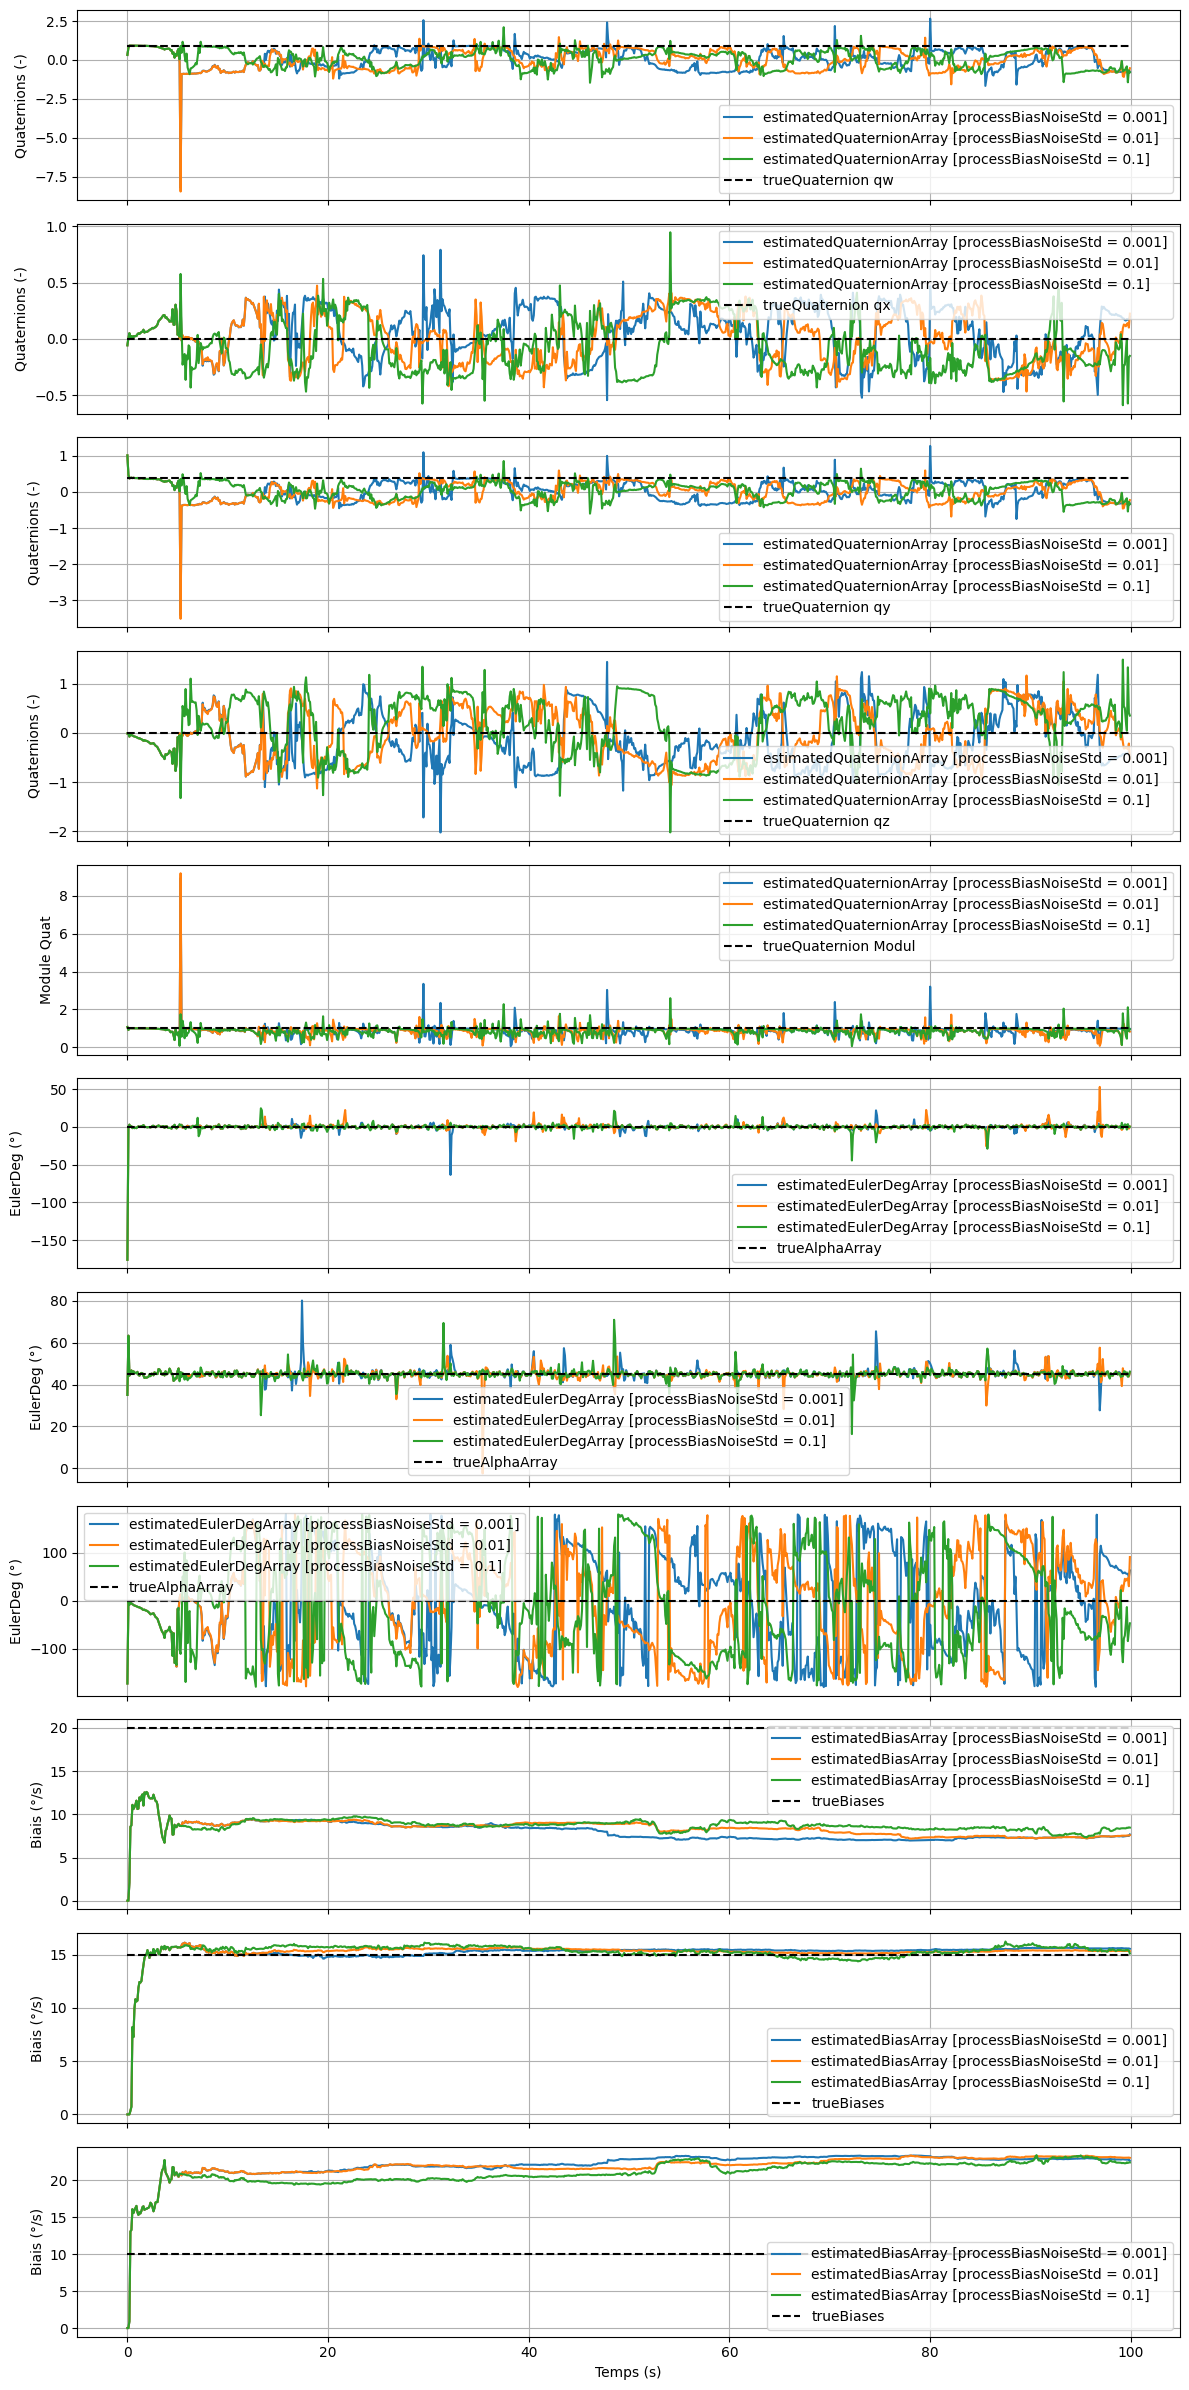

In [16]:
trueBiases = np.tile(
    [simConfig.trueInitialBiasX,
     simConfig.trueInitialBiasY,
     simConfig.trueInitialBiasZ],
    (simConfig.sampleSize, 1))

fig, axes = plt.subplots(11, 1, figsize=(12, 24), sharex=True)
for res in results:
    axes[0].plot(timeArray, res.estimatedQuaternionArray[:,0], label="estimatedQuaternionArray "+res.label)
    axes[1].plot(timeArray, res.estimatedQuaternionArray[:,1], label="estimatedQuaternionArray "+res.label)
    axes[2].plot(timeArray, res.estimatedQuaternionArray[:,2], label="estimatedQuaternionArray "+res.label)
    axes[3].plot(timeArray, res.estimatedQuaternionArray[:,3], label="estimatedQuaternionArray "+res.label)
    axes[4].plot(timeArray, np.linalg.norm(res.estimatedQuaternionArray, axis=-1), label="estimatedQuaternionArray "+res.label)
    axes[5].plot(timeArray, res.estimatedEulerDegArray[:,0], label="estimatedEulerArray "+res.label)
    axes[6].plot(timeArray, res.estimatedEulerDegArray[:,1], label="estimatedEulerArray "+res.label)
    axes[7].plot(timeArray, res.estimatedEulerDegArray[:,2], label="estimatedEulerArray "+res.label)
    axes[8].plot(timeArray, res.estimatedBiasArray[:,0], label="estimatedBiasArray "+res.label)
    axes[9].plot(timeArray, res.estimatedBiasArray[:,1], label="estimatedBiasArray "+res.label)
    axes[10].plot(timeArray, res.estimatedBiasArray[:,2], label="estimatedBiasArray "+res.label)

axes[0].plot(timeArray, trueQuaternionArray[:,0], 'k--', label="trueQuaternion qw")
axes[1].plot(timeArray, trueQuaternionArray[:,1], 'k--', label="trueQuaternion qx")
axes[2].plot(timeArray, trueQuaternionArray[:,2], 'k--', label="trueQuaternion qy")
axes[3].plot(timeArray, trueQuaternionArray[:,3], 'k--', label="trueQuaternion qz")
axes[4].plot(timeArray, np.linalg.norm(trueQuaternionArray, axis=-1), 'k--', label="trueQuaternion Modul")

axes[5].plot(timeArray, [0]*simConfig.sampleSize, 'k--', label="trueAlphaArray")
axes[6].plot(timeArray, trueAlphaArray, 'k--', label="trueAlphaArray")
axes[7].plot(timeArray, [0]*simConfig.sampleSize, 'k--', label="trueAlphaArray")
axes[8].plot(timeArray, trueBiases[:,0], 'k--', label="trueBiases")
axes[9].plot(timeArray, trueBiases[:,1], 'k--', label="trueBiases")
axes[10].plot(timeArray, trueBiases[:,2], 'k--', label="trueBiases")

# titles = [np.reshape(["Quaternions (-)"]*4, (4,1)), np.reshape(["EulerDeg (°)"]*3, (3,1)), np.reshape(["Biais (°/s)"]*3, (3,1))]
# titles = np.reshape(titles, (10, 1, 1))
titles = ["Quaternions (-)"]*4 + ["Module Quat"] + ["EulerDeg (°)"]*3 + ["Biais (°/s)"]*3
for ax, title in zip(axes, titles):
    ax.set_ylabel(title)
    ax.legend()
    ax.grid(True)

axes[10].set_xlabel("Temps (s)")
plt.tight_layout()
plt.show()


In [17]:
colors = ["blue", "green", "cyan", "brown"]
linestyles = ['-', '--', '-.', ':']

In [18]:
plt.figure(figsize=(15, 5))

plt.plot(TimeArray,
         TrueAlphaArray,
         label="TrueAlpha",
         color="grey",
         linewidth=1)

plt.scatter(TimeArray,
            MeasuredAccelXArray,
            label="MeasuredAccelX",
            color="red",
            s=4,
            alpha=0.6)

plt.scatter(TimeArray,
            MeasuredAccelYArray,
            label="MeasuredAccelY",
            color="orange",
            s=4,
            alpha=0.6)

for res, color, linestyle in zip(results, colors, linestyles):
    plt.plot(TimeArray,
            res.estimatedAlphaArray,
             label="EstimatedAlpha (Kalman) "+res.label,
             linestyle = linestyle,
             color=color,
             linewidth=1)

plt.title("IMU Kalman Filtering – Alpha Tracking")
plt.xlabel("Time (s)")
plt.ylabel("Angle")

if doClip:
    plt.ylim(alphaMin, alphaMax)

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

NameError: name 'TimeArray' is not defined

<Figure size 1500x500 with 0 Axes>

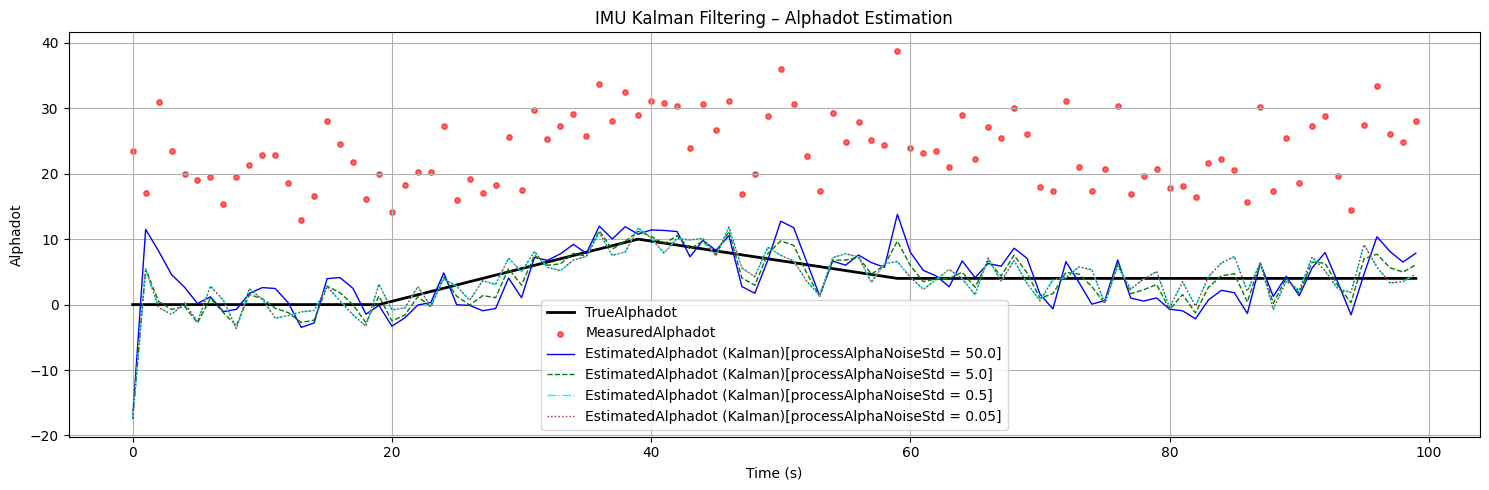

In [42]:
plt.figure(figsize=(15, 5))  # <<<

plt.plot(TimeArray,
         TrueAlphadotArray,
         label="TrueAlphadot",
         color="black",
         linewidth=2)  # <<<

plt.scatter(TimeArray,
            MeasuredAlphadotArray,
            label="MeasuredAlphadot",
            color="red",
            s=15,
            alpha=0.6)

for res, color, linestyle in zip(results, colors, linestyles):
    plt.plot(TimeArray,
            res.estimatedAlphadotArray,
             label="EstimatedAlphadot (Kalman)"+res.label,
             linestyle = linestyle,
             color=color,
             linewidth=1)


plt.title("IMU Kalman Filtering – Alphadot Estimation")  # <<<
plt.xlabel("Time (s)")
plt.ylabel("Alphadot")  # <<<

if doClip:
    plt.ylim(alphadotMin, alphadotMax)

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

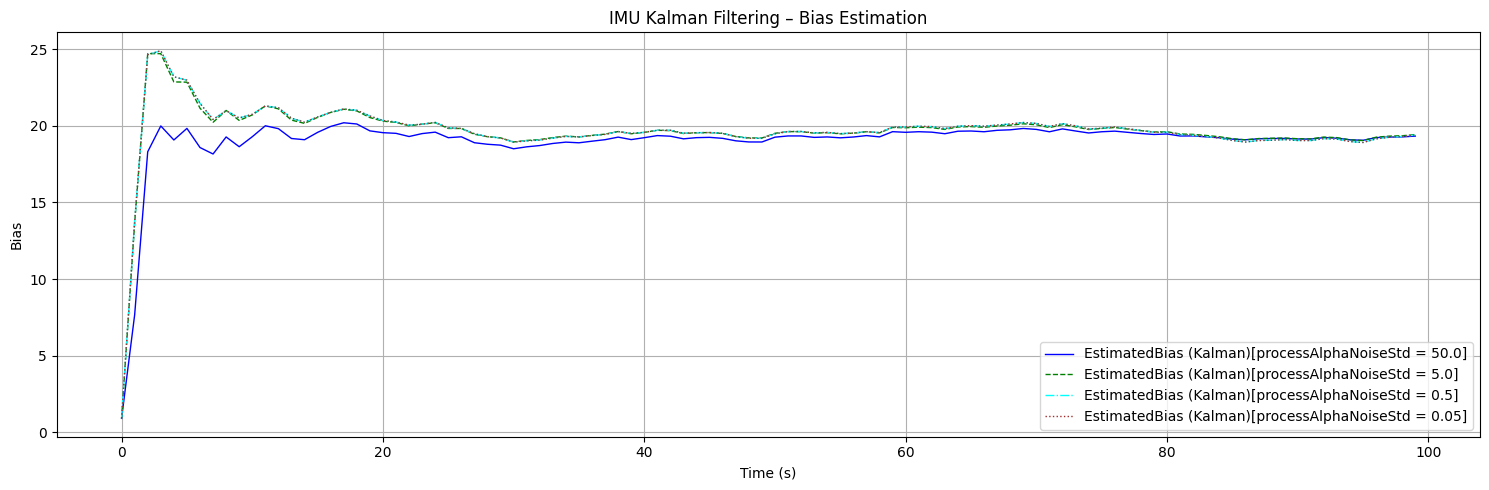

In [43]:
plt.figure(figsize=(15, 5))  # <<<

for res, color, linestyle in zip(results, colors, linestyles):
    plt.plot(TimeArray,
            res.estimatedBiasArray,
             label="EstimatedBias (Kalman)"+res.label,
             linestyle = linestyle,
             color=color,
             linewidth=1)


plt.title("IMU Kalman Filtering – Bias Estimation")  # <<<
plt.xlabel("Time (s)")
plt.ylabel("Bias")  # <<<

if doClip:
    plt.ylim(biasMin, biasMax)

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()